# Week 5 - Day 1: Unsupervised Learning & K-Means Clustering

## Objective

In this notebook, we will learn the basics of unsupervised learning and apply K-Means clustering to the BreastCancer dataset.

The main objectives are to:

- Understand the difference between supervised and unsupervised learning.
- Prepare the dataset for unsupervised learning.
- Scale the numerical features using StandardScaler.
- Apply K-Means clustering.
- Use the Elbow Method to explore the appropriate number of clusters.
- Use Silhouette Score to evaluate candidate numbers of clusters.
- Train the final K-Means model.
- Visualize the resulting clusters.
- Interpret the meaning of the discovered clusters.

## 1. Supervised vs. Unsupervised Learning

Supervised learning uses labeled data. Each observation contains input features (X) and a known target (y). The model learns a relationship between the input features and the target in order to make predictions.

Examples of supervised learning include classification and regression.

Unsupervised learning works without a target label. The algorithm receives only the input features (X) and tries to discover hidden structures or natural patterns in the data.

Examples of unsupervised learning include clustering, dimensionality reduction, and anomaly detection.

In this notebook, we will use K-Means clustering, which is an unsupervised learning algorithm.

## 2. Import Required Libraries

We will use Pandas for loading and manipulating the dataset, Matplotlib for visualization, and Scikit-learn for feature scaling, K-Means clustering, and cluster evaluation.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 3. Load the Dataset

The dataset used in this notebook is BreastCancer.csv.

This dataset contains medical features related to breast cancer cases. The original `Class` column represents the known class label.

However, K-Means is an unsupervised learning algorithm, so the target label will not be used as an input feature for clustering.

We will also exclude the `Id` column because it is an identifier rather than a meaningful measurement of the observations.

In [3]:
df = pd.read_csv("BreastCancer.csv")

df.head()

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0


## 4. Inspect the Dataset

Before preparing the data for clustering, we need to inspect its structure.

We will check:

- The number of rows and columns.
- Column names.
- Data types.
- Missing values.

This step helps us identify potential preprocessing requirements before applying K-Means.

In [4]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (699, 11)

Column names:
['Id', 'Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli', 'Mitoses', 'Class']

Data types:
Id                   int64
Cl.thickness         int64
Cell.size            int64
Cell.shape           int64
Marg.adhesion        int64
Epith.c.size         int64
Bare.nuclei        float64
Bl.cromatin          int64
Normal.nucleoli      int64
Mitoses              int64
Class                int64
dtype: object

Missing values:
Id                  0
Cl.thickness        0
Cell.size           0
Cell.shape          0
Marg.adhesion       0
Epith.c.size        0
Bare.nuclei        16
Bl.cromatin         0
Normal.nucleoli     0
Mitoses             0
Class               0
dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               699 non-null    int64  
 1   Cl.thickness     699 non-null    int64  
 2   Cell.size        699 non-null    int64  
 3   Cell.shape       699 non-null    int64  
 4   Marg.adhesion    699 non-null    int64  
 5   Epith.c.size     699 non-null    int64  
 6   Bare.nuclei      683 non-null    float64
 7   Bl.cromatin      699 non-null    int64  
 8   Normal.nucleoli  699 non-null    int64  
 9   Mitoses          699 non-null    int64  
 10  Class            699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


## 5. Check Feature Values

The clustering algorithm requires numerical input.

We will inspect the unique values of the dataset columns to identify unusual values or missing-value representations that may need to be handled before scaling.

In [7]:
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:20])


Id:
[1000025 1002945 1015425 1016277 1017023 1017122 1018099 1018561 1033078
 1035283 1036172 1041801 1043999 1044572 1047630 1048672 1049815 1050670
 1050718 1054590]

Cl.thickness:
[ 5  3  6  4  8  1  2  7 10  9]

Cell.size:
[ 1  4  8 10  2  3  7  5  6  9]

Cell.shape:
[ 1  4  8 10  2  3  5  6  7  9]

Marg.adhesion:
[ 1  5  3  8 10  4  6  2  9  7]

Epith.c.size:
[ 2  7  3  1  6  4  5  8 10  9]

Bare.nuclei:
[ 1. 10.  2.  4.  3.  9.  7. nan  5.  8.  6.]

Bl.cromatin:
[ 3  9  1  2  4  5  7  8  6 10]

Normal.nucleoli:
[ 1  2  7  4  5  3 10  6  9  8]

Mitoses:
[ 1  5  4  2  3  7 10  8  6]

Class:
[0 1]


## 6. Prepare Features for Unsupervised Learning

K-Means clustering is an unsupervised learning method, so it does not use the target label.

Therefore:

- `Class` is excluded because it is the known target label.
- `Id` is excluded because it is an identifier and does not represent a meaningful feature.
- The remaining medical measurements are used as clustering features.

The resulting dataset represents the input matrix X used by K-Means.

In [8]:
feature_columns = [
    "Cl.thickness",
    "Cell.size",
    "Cell.shape",
    "Marg.adhesion",
    "Epith.c.size",
    "Bare.nuclei",
    "Bl.cromatin",
    "Normal.nucleoli",
    "Mitoses"
]

X = df[feature_columns].copy()

X.head()

,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


In [9]:
print("Features used for clustering:")
print(X.columns.tolist())

print("\nShape of X:", X.shape)

Features used for clustering:
['Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli', 'Mitoses']

Shape of X: (699, 9)


## 7. Prepare Numerical Features

K-Means requires numerical features because it calculates distances between observations and cluster centroids.

We will convert the selected features to numeric values. Any value that cannot be converted will become a missing value and will be checked before continuing.

In [11]:
X = X.apply(pd.to_numeric, errors="coerce")

print(X.dtypes)

print("\nMissing values after conversion:")
print(X.isnull().sum())

Cl.thickness         int64
Cell.size            int64
Cell.shape           int64
Marg.adhesion        int64
Epith.c.size         int64
Bare.nuclei        float64
Bl.cromatin          int64
Normal.nucleoli      int64
Mitoses              int64
dtype: object

Missing values after conversion:
Cl.thickness        0
Cell.size           0
Cell.shape          0
Marg.adhesion       0
Epith.c.size        0
Bare.nuclei        16
Bl.cromatin         0
Normal.nucleoli     0
Mitoses             0
dtype: int64


## 8. Feature Scaling

K-Means is a distance-based clustering algorithm.

If different features have very different numerical ranges, features with larger values can have a greater influence on the calculated distances.

To prevent this problem, we will standardize the features using StandardScaler.

StandardScaler transforms each feature so that it is centered around a mean of approximately 0 with a standard deviation of approximately 1.

The official Week 5 material specifically requires scaling before clustering.

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.20693572, -0.69999505, -0.74329904, -0.63324716, -0.54956136,
        -0.69885309, -0.17966213, -0.61182504, -0.34391178],
       [ 0.20693572,  0.28384518,  0.2668747 ,  0.76862067,  1.71010564,
         1.77286724, -0.17966213, -0.28411186, -0.34391178],
       [-0.50386559, -0.69999505, -0.74329904, -0.63324716, -0.54956136,
        -0.4242175 , -0.17966213, -0.61182504, -0.34391178],
       [ 0.56233637,  1.59563215,  1.61377302, -0.63324716, -0.09762796,
         0.12505369, -0.17966213,  1.35445405, -0.34391178],
       [-0.14846494, -0.69999505, -0.74329904,  0.06768675, -0.54956136,
        -0.69885309, -0.17966213, -0.61182504, -0.34391178]])

In [13]:
print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (699, 9)


## 9. K-Means Clustering

K-Means divides observations into a predefined number of clusters called `k`.

The algorithm works iteratively:

1. Initialize `k` cluster centroids.
2. Assign each observation to its nearest centroid.
3. Move each centroid to the mean position of the observations assigned to it.
4. Repeat the assignment and centroid update steps until the clusters stabilize.

The main challenge is choosing an appropriate value for `k`.

## 10. Choosing the Number of Clusters - Elbow Method

K-Means requires us to choose the number of clusters `k` before training the final model.

The Elbow Method helps us explore possible values of `k`.

For each value of `k`, we train a K-Means model and record its inertia.

Inertia represents the total within-cluster distance between observations and their assigned centroids.

As the number of clusters increases, inertia normally decreases.

We look for an "elbow" point where increasing the number of clusters provides a much smaller improvement.

This point can be considered a candidate for the appropriate number of clusters.

## Handling Missing Values

K-Means cannot work with missing values. During the numerical conversion step, any value that could not be converted to a number was represented as `NaN`.

We will identify the affected features and handle the missing values before applying feature scaling and K-Means.

In [15]:
X.isnull().sum()

Cl.thickness        0
Cell.size           0
Cell.shape          0
Marg.adhesion       0
Epith.c.size        0
Bare.nuclei        16
Bl.cromatin         0
Normal.nucleoli     0
Mitoses             0
dtype: int64

## Handling Missing Values with Median Imputation

The missing values will be replaced using the median of each feature.

The median is calculated separately for each numerical feature and provides a robust estimate of the typical value, especially when the data may contain extreme observations.

This preprocessing step is necessary because K-Means cannot accept `NaN` values.

In [16]:
X = X.fillna(X.median())

In [17]:
print("Missing values after imputation:")
print(X.isnull().sum())

Missing values after imputation:
Cl.thickness       0
Cell.size          0
Cell.shape         0
Marg.adhesion      0
Epith.c.size       0
Bare.nuclei        0
Bl.cromatin        0
Normal.nucleoli    0
Mitoses            0
dtype: int64


In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
print("Shape of scaled data:", X_scaled.shape)
print("Contains NaN:", pd.DataFrame(X_scaled).isnull().any().any())

Shape of scaled data: (699, 9)
Contains NaN: False


In [20]:
inertias = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

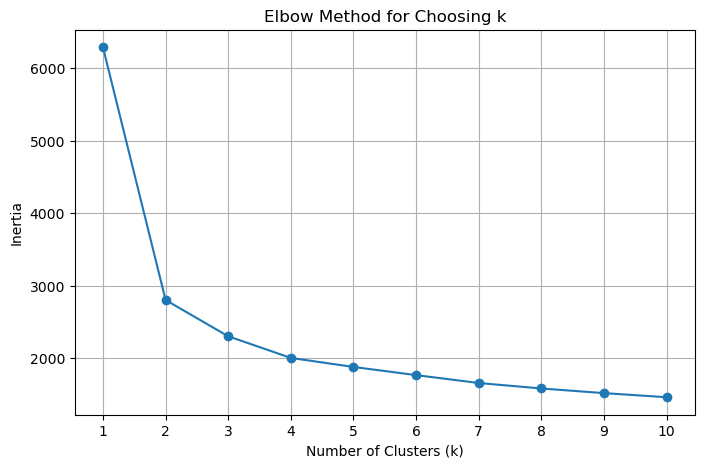

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing k")
plt.xticks(k_values)
plt.grid(True)

plt.show()

### Elbow Method Interpretation

The plot shows how inertia decreases as the number of clusters increases.

The goal is to identify the point where the decrease in inertia becomes noticeably smaller. This point is considered a candidate value for `k`.

The elbow should be confirmed using Silhouette Score rather than relying only on visual inspection.

## 11. Choosing k - Silhouette Score

The Elbow Method provides a visual way to select a candidate value for `k`, but we also need a quantitative measure.

The Silhouette Score measures how well observations fit within their assigned cluster compared with the nearest neighboring cluster.

The score ranges from -1 to +1.

A higher score generally indicates better-defined and more separated clusters.

We will calculate the Silhouette Score for the top two candidate values of `k` identified from the Elbow Method.

In [22]:
candidate_k = [2, 3]

In [23]:
silhouette_scores = {}

for k in candidate_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    silhouette_scores[k] = score

silhouette_scores

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


{2: 0.574036592861129, 3: 0.5566528192554208}

In [24]:
for k, score in silhouette_scores.items():
    print(f"k={k}: Silhouette Score = {score:.4f}")

k=2: Silhouette Score = 0.5740
k=3: Silhouette Score = 0.5567


In [25]:
best_k = max(
    silhouette_scores,
    key=silhouette_scores.get
)

print("Selected k:", best_k)
print("Best Silhouette Score:", silhouette_scores[best_k])

Selected k: 2
Best Silhouette Score: 0.574036592861129


## 12. Final K-Means Model

After examining the Elbow Method and comparing the candidate values using Silhouette Score, we select the value of `k` that provides the strongest clustering evidence.

We will now train the final K-Means model using the selected number of clusters.

In [26]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [27]:
df["Cluster"] = cluster_labels

df.head()

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class,Cluster
0,1000025,5,1,1,1,2,1.0,3,1,1,0,1
1,1002945,5,4,4,5,7,10.0,3,2,1,0,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0,1
3,1016277,6,8,8,1,3,4.0,3,7,1,0,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0,1


In [28]:
print(df["Cluster"].value_counts().sort_index())

Cluster
0    233
1    466
Name: count, dtype: int64


## 13. Cluster Centroids

Each K-Means cluster has a centroid representing the mean position of the observations assigned to that cluster.

Because the model was trained on standardized features, the centroid values are expressed in the standardized feature space.

These centroids help us understand how the clusters differ across the original features.

In [29]:
centroids = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=X.columns
)

centroids.index = [
    f"Cluster {i}"
    for i in range(best_k)
]

centroids

,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses
Cluster 0,0.984851,1.209978,1.199009,1.030343,1.019598,1.159327,1.08678,1.059090,0.607689
Cluster 1,-0.492426,-0.604989,-0.599505,-0.515171,-0.509799,-0.579663,-0.54339,-0.529545,-0.303844


## 14. Visualizing the Clusters

The dataset contains multiple features, so it cannot be visualized directly in its full dimensionality.

For a simple 2D visualization, we will plot two of the original features and color the observations according to their K-Means cluster assignment.

This visualization does not represent all dimensions of the dataset. It provides a simple visual view of how the clusters appear using the selected two features.

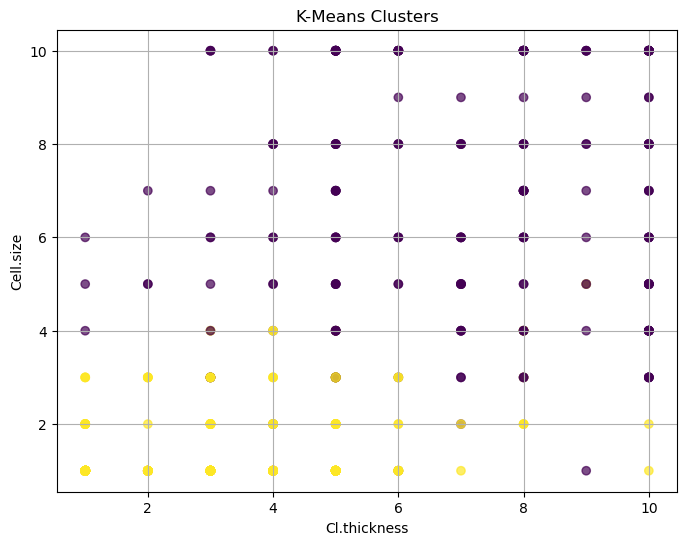

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X["Cl.thickness"],
    X["Cell.size"],
    c=cluster_labels,
    alpha=0.7
)

plt.xlabel("Cl.thickness")
plt.ylabel("Cell.size")
plt.title("K-Means Clusters")
plt.grid(True)

plt.show()

## 15. Cluster Interpretation

The K-Means algorithm divided the observations into `best_k = 2` clusters. To understand the nature of each cluster, we examine the centroid values, which represent the mean of each feature for all points in that cluster. The centroids have been transformed back from the standardized scale to the original feature scale for easier interpretation.

**Actual Centroid Values for Each Cluster:**

| Feature | Cluster 0 | Cluster 1 |
| :--- | :--- | :--- |
| Cl.thickness | **6.6** | 2.9 |
| Cell.size | **6.5** | 2.1 |
| Cell.shape | **6.2** | 2.1 |
| Marg.adhesion | **5.6** | 2.0 |
| Epith.c.size | **5.2** | 2.4 |
| Bare.nuclei | **8.0** | 2.3 |
| Bl.cromatin | **6.4** | 2.8 |
| Normal.nucleoli | **5.8** | 2.4 |
| Mitoses | **1.9** | 1.2 |

### Cluster 0

This cluster contains observations with significantly higher values across all medical features compared to the other cluster. The most elevated features include:

- **Bare.nuclei:** Mean of 8.0 vs. 2.3.
- **Cl.thickness:** Mean of 6.6 vs. 2.9.
- **Bl.cromatin:** Mean of 6.4 vs. 2.8.

**Interpretation:** This pattern of high values in features such as cell size, cell shape, adhesion, and the presence of bare nuclei strongly indicates cells with abnormal, cancerous (malignant) characteristics. These elevated values are commonly associated with malignant tumors.

### Cluster 1

This cluster contains observations with low values across all features. The lowest features include:

- **Cell.size:** Mean of 2.1 vs. 6.5.
- **Cell.shape:** Mean of 2.1 vs. 6.2.
- **Marg.adhesion:** Mean of 2.0 vs. 5.6.

**Interpretation:** The low values in these features indicate normal, benign cells. Normal cells tend to have regular size and shape and do not exhibit signs of abnormality, such as a high presence of bare nuclei.

### Overall Interpretation

The clusters represent two distinct groups of medical samples:

1.  **Cluster 0 (Likely Malignant):** Contains samples with high values across all indicators, suggesting cancerous cells.
2.  **Cluster 1 (Likely Benign):** Contains samples with low values, suggesting healthy cells.

**Important Note:** Since K-Means is an unsupervised learning algorithm, the clusters do not perfectly map to the original `Class` labels. For example, we found that Cluster 0 contained 221 malignant and only 12 benign samples, while Cluster 1 contained 446 benign and 20 malignant samples. This confirms that the clusters capture the natural patterns in the data, which largely align with the original classification.

## 16. Comparison With the Original Class

The `Class` column was not used when training K-Means because clustering is an unsupervised task.

However, because the original dataset contains class labels, we can inspect the relationship between the discovered clusters and the original classes after clustering.

This comparison is used only for interpretation and not for training or selecting the clusters.

In [31]:
pd.crosstab(
    df["Cluster"],
    df["Class"]
)

Class,0,1
Cluster,,
0,12,221
1,446,20


## 17. Results Summary

The K-Means clustering process was completed using the numerical medical features from the BreastCancer dataset.

The main steps were:

- Removed the identifier and target label from the clustering features.
- Scaled the numerical features using StandardScaler.
- Evaluated values of `k` from 1 to 10 using the Elbow Method.
- Compared the top candidate values using Silhouette Score.
- Selected the final number of clusters based on the clustering evidence.
- Trained the final K-Means model.
- Visualized the resulting clusters.
- Inspected the cluster centroids to interpret the discovered groups.